File1: Customer_Comment Cleaning

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Customer_comment.csv')

# Display the head
print("Head of the DataFrame:")
display(df.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df.tail())

# Display the info
print("\nInfo of the DataFrame:")
df.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df.describe())

Head of the DataFrame:


,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal



Tail of the DataFrame:


,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
9419,9419,2175,YYX,ORX,2022-09-30,Early & Ontime,Early & Ontime,Domestic,tapas box needs better pita chips. the provide...,90+,Is there anything else you'd like to share abo...,premier gold,B737-700,Mainline,member,Neutral,tapa box need better pita chip provid chip alw...
9420,9420,680,DEX,GRX,2022-09-30,Delayed,Delayed,Domestic,My flight attendant missed my drink order 2x a...,80+,Is there anything else you'd like to share abo...,global services,B737-900,Mainline,member,Neutral,flight attend miss drink order 2x end never re...
9421,9421,1420,CLX,FLX,2022-09-29,Delayed,Early & Ontime,Domestic,Mo.,70+,Is there anything else you'd like to share abo...,premier platinum,B737-800,Mainline,member,Negative,mo
9422,9422,4746,LAX,EUX,2022-09-30,Early & Ontime,Early & Ontime,Domestic,"without a smartphone, not much to eat. we pack...",80+,Is there anything else you'd like to share abo...,NaN,ERJ-175,Express,non-member,Neutral,without smartphon much eat pack food email foo...
9423,9423,3773,IAX,YOX,2022-09-30,Delayed,Delayed,Domestic,Offering coffee or tea would also be great.,90+,Is there anything else you'd like to share abo...,NaN,CRJ-200,Express,non-member,Neutral,offer coffe tea would also great



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9424 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                9424 non-null   int64 
 1   flight_number             9424 non-null   int64 
 2   origin_station_code       9424 non-null   object
 3   destination_station_code  9424 non-null   object
 4   scheduled_departure_date  9424 non-null   object
 5   arrival_delay_group       9424 non-null   object
 6   departure_delay_group     9424 non-null   object
 7   entity                    9424 non-null   object
 8   verbatim_text             9424 non-null   object
 9   seat_factor_band          9424 non-null   object
 10  ques_verbatim_text        9424 non-null   object
 11  loyalty_program_level     6920 non-null   object
 12  fleet_type_description    9424 non-null   object
 13  fleet_usage               9424 non-null   object
 14  

,Unnamed: 0,flight_number
count,9424.000000,9424.000000
mean,4711.500000,1741.573430
std,2720.618802,1550.550037
min,0.000000,2.000000
25%,2355.750000,614.000000
50%,4711.500000,1286.000000
75%,7067.250000,2261.000000
max,9423.000000,6375.000000


In [5]:
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Unnamed: 0,0
flight_number,0
origin_station_code,0
destination_station_code,0
scheduled_departure_date,0
arrival_delay_group,0
departure_delay_group,0
entity,0
verbatim_text,0
seat_factor_band,0


In [6]:
missing_text_df = df[df['transformed_text'].isnull()]
print("Verbatim text for rows with missing transformed_text:")
display(missing_text_df[['verbatim_text', 'transformed_text']].head())
display(missing_text_df[['verbatim_text', 'transformed_text']].tail())

Verbatim text for rows with missing transformed_text:


,verbatim_text,transformed_text
11,no.,NaN
27,No.,NaN
42,no.,NaN
43,no.,NaN
44,No.,NaN


,verbatim_text,transformed_text
9391,no.,NaN
9394,No.,NaN
9398,No.,NaN
9406,No.,NaN
9413,No.,NaN


In [7]:
df['transformed_text_missing'] = df['transformed_text'].isnull().astype(int)

print("\nValue counts for the new indicator column:")
display(df['transformed_text_missing'].value_counts())


Value counts for the new indicator column:


,count
transformed_text_missing,
0,8405
1,1019


In [8]:
df['loyalty_program_level'] = df['loyalty_program_level'].fillna('Unknown')

print("\nMissing values after handling loyalty_program_level:")
display(df.isnull().sum())


Missing values after handling loyalty_program_level:


,0
Unnamed: 0,0
flight_number,0
origin_station_code,0
destination_station_code,0
scheduled_departure_date,0
arrival_delay_group,0
departure_delay_group,0
entity,0
verbatim_text,0
seat_factor_band,0


In [9]:
df.drop('Unnamed: 0', axis=1, inplace=True)

print("\nDataFrame after dropping 'Unnamed: 0':")
display(df.head())


DataFrame after dropping 'Unnamed: 0':


,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text,transformed_text_missing
0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...,0
1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,Unknown,B777-200,Mainline,non-member,Neutral,choic,0
2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack,0
3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...,0
4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal,0


In [10]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 2
Number of duplicate rows after dropping: 0


In [11]:
df['scheduled_departure_date'] = pd.to_datetime(df['scheduled_departure_date'])

print("\nData types after converting scheduled_departure_date:")
display(df.info())


Data types after converting scheduled_departure_date:
<class 'pandas.core.frame.DataFrame'>
Index: 9422 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   flight_number             9422 non-null   int64         
 1   origin_station_code       9422 non-null   object        
 2   destination_station_code  9422 non-null   object        
 3   scheduled_departure_date  9422 non-null   datetime64[ns]
 4   arrival_delay_group       9422 non-null   object        
 5   departure_delay_group     9422 non-null   object        
 6   entity                    9422 non-null   object        
 7   verbatim_text             9422 non-null   object        
 8   seat_factor_band          9422 non-null   object        
 9   ques_verbatim_text        9422 non-null   object        
 10  loyalty_program_level     9422 non-null   object        
 11  fleet_type_description    9422 n

None

File2: Passenger_booking Cleaning

In [12]:
# Load the dataset
df2 = pd.read_csv('/content/Passanger_booking_data.csv')

# Display the head
print("Head of the DataFrame:")
display(df2.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df2.tail())

# Display the info
print("\nInfo of the DataFrame:")
df2.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df2.describe())

Head of the DataFrame:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,21,12,6,Tue,AKLHGH,Australia,0,0,0,7.21,1
1,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
2,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
3,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
4,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0



Tail of the DataFrame:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
49997,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0
49998,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0
49999,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0
50000,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0
50001,1,Internet,RoundTrip,19,6,10,Thu,PERPNH,Australia,0,1,0,5.62,0



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50002 entries, 0 to 50001
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50002 non-null  int64  
 1   sales_channel          50002 non-null  object 
 2   trip_type              50002 non-null  object 
 3   purchase_lead          50002 non-null  int64  
 4   length_of_stay         50002 non-null  int64  
 5   flight_hour            50002 non-null  int64  
 6   flight_day             50002 non-null  object 
 7   route                  50002 non-null  object 
 8   booking_origin         50002 non-null  object 
 9   wants_extra_baggage    50002 non-null  int64  
 10  wants_preferred_seat   50002 non-null  int64  
 11  wants_in_flight_meals  50002 non-null  int64  
 12  flight_duration        50002 non-null  float64
 13  booking_complete       50002 non-null  int64  
dtypes: float64(1), int64(8), objec

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000
mean,1.591256,84.940582,23.044778,9.066277,0.668773,0.296968,0.427143,7.277524,0.149574
std,1.020167,90.450548,33.887171,5.412569,0.470659,0.456927,0.494668,1.496854,0.356657
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.000000,5.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.000000,9.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.000000,13.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.000000,23.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [13]:
print("\nMissing values per column:")
display(df2.isnull().sum())


Missing values per column:


,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [14]:
print("Number of duplicate rows before dropping:", df2.duplicated().sum())

df2.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df2.duplicated().sum())

Number of duplicate rows before dropping: 719
Number of duplicate rows after dropping: 0


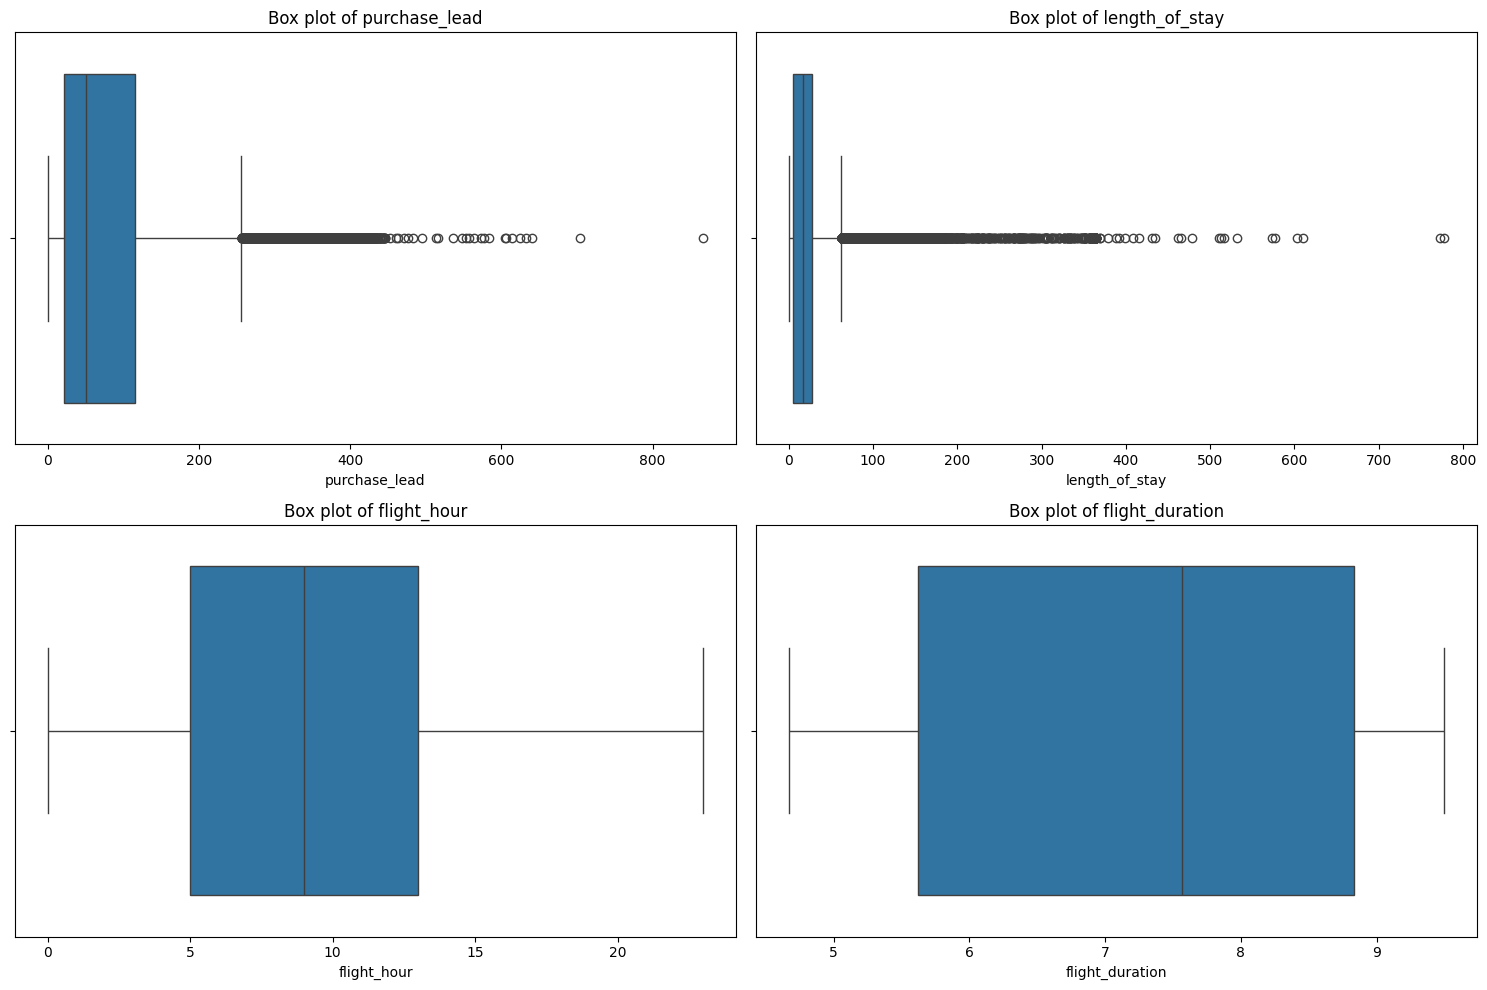

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df2[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [16]:
# Investigate outliers in 'purchase_lead'
print("Rows with high 'purchase_lead' values:")
display(df2[df2['purchase_lead'] > 600].head()) # Displaying rows with purchase_lead > 600 as outliers are beyond this based on the box plot

# Investigate outliers in 'length_of_stay'
print("\nRows with high 'length_of_stay' values:")
display(df2[df2['length_of_stay'] > 500].head()) # Displaying rows with length_of_stay > 500 as outliers are beyond this based on the box plot

Rows with high 'purchase_lead' values:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
837,3,Internet,RoundTrip,641,46,6,Sun,AKLKUL,Malaysia,1,0,1,8.83,1
6150,1,Internet,RoundTrip,614,19,11,Wed,COKMEL,Australia,0,0,0,8.83,0
24121,1,Internet,RoundTrip,704,23,8,Tue,PNHSYD,Australia,0,0,0,8.58,0
38358,2,Internet,RoundTrip,633,5,10,Sat,HKTOOL,Australia,0,0,1,8.83,0
39419,1,Mobile,RoundTrip,625,5,15,Fri,ICNRGN,Myanmar (Burma),0,0,0,6.62,0



Rows with high 'length_of_stay' values:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
1585,2,Internet,RoundTrip,32,603,0,Thu,AKLKUL,Malaysia,0,0,0,8.83,0
10296,1,Internet,RoundTrip,10,610,2,Mon,DMKSYD,Australia,1,1,0,8.58,0
10823,1,Internet,RoundTrip,102,778,8,Wed,DPSMEL,Australia,0,0,0,8.83,1
13216,1,Internet,RoundTrip,20,532,11,Thu,HYDPER,India,1,0,1,5.62,0
13441,1,Mobile,RoundTrip,18,513,10,Sat,HYDSYD,India,1,1,1,8.58,0


In [17]:
# Apply capping to 'purchase_lead' at the 95th percentile
purchase_lead_cap = df2['purchase_lead'].quantile(0.95)
df2['purchase_lead'] = df2['purchase_lead'].clip(upper=purchase_lead_cap)

# Apply capping to 'length_of_stay' at the 95th percentile
length_of_stay_cap = df2['length_of_stay'].quantile(0.95)
df2['length_of_stay'] = df2['length_of_stay'].clip(upper=length_of_stay_cap)

print("Descriptive statistics after capping:")
display(df2[['purchase_lead', 'length_of_stay']].describe())

Descriptive statistics after capping:


,purchase_lead,length_of_stay
count,49283.000000,49283.000000
mean,81.604772,20.710306
std,81.207474,21.818939
min,0.000000,0.000000
25%,21.000000,5.000000
50%,51.000000,17.000000
75%,115.000000,28.000000
max,287.000000,84.000000


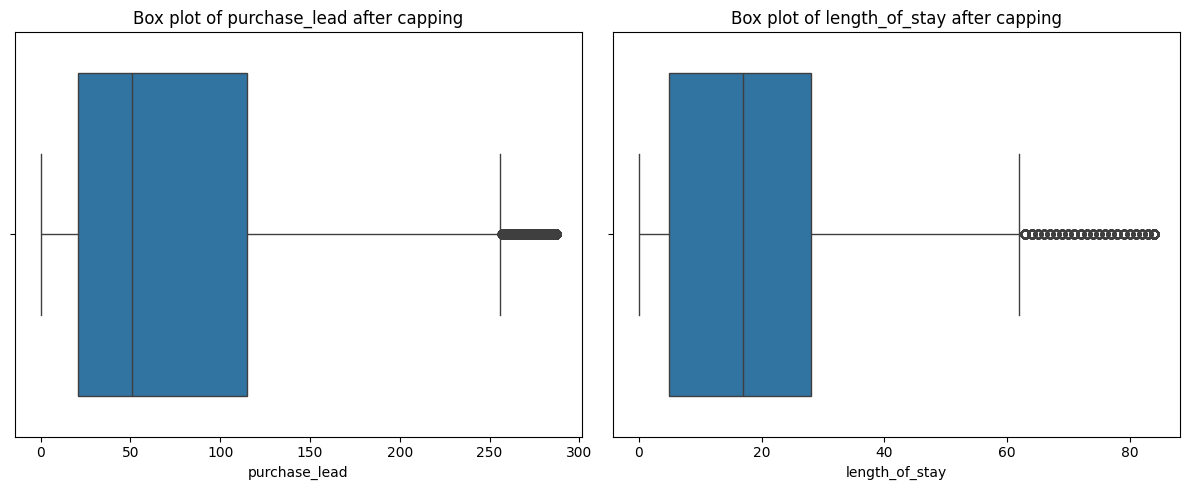

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df2['purchase_lead'])
plt.title('Box plot of purchase_lead after capping')

plt.subplot(1, 2, 2)
sns.boxplot(x=df2['length_of_stay'])
plt.title('Box plot of length_of_stay after capping')

plt.tight_layout()
plt.show()

File3: Survey_Data_Inflight_Satisfaction Cleaning

In [19]:
import pandas as pd

# Load the dataset
df3 = pd.read_csv('/content/Survey data_Inflight Satisfaction Score.csv')

# Display the head
print("Head of the DataFrame:")
display(df3.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df3.tail())

# Display the info
print("\nInfo of the DataFrame:")
df3.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df3.describe())

Head of the DataFrame:


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure



Tail of the DataFrame:


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
47069,2,SFX,SIX,IPXXM3,9/30/2022,How satisfied were you with the food & beverag...,4,Satisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,G9,F52,International,non-member,PANASONIC,hub departure
47070,2,SFX,SIX,O5XXK4,9/30/2022,How satisfied were you with the food & beverag...,4,Satisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,G9,F52,International,member,PANASONIC,hub departure
47071,3,SIX,SFX,G8XX3W,9/30/2022,How satisfied were you with the food & beverag...,1,Dissatisfied,food & beverage,food and beverage satisfaction,...,78P,UA,8440,Long,F52,G2,International,member,PANASONIC,spoke departure
47072,3,SIX,SFX,G8XX3W,9/30/2022,What item did you choose?,chicken entrée,NaN,food & beverage,comp,...,78P,UA,8440,Long,F52,G2,International,member,PANASONIC,spoke departure
47073,2,SFX,SIX,O5XXK4,9/30/2022,What item did you choose?,chicken entrée,NaN,food & beverage,comp,...,78P,UA,8440,Long,G9,F52,International,member,PANASONIC,hub departure



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47074 entries, 0 to 47073
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   flight_number                     47074 non-null  int64 
 1   origin_station_code               47074 non-null  object
 2   destination_station_code          47074 non-null  object
 3   record_locator                    47074 non-null  object
 4   scheduled_departure_date          47074 non-null  object
 5   question_text                     47074 non-null  object
 6   score                             47074 non-null  object
 7   satisfaction_type                 34963 non-null  object
 8   driver_sub_group1                 47074 non-null  object
 9   driver_sub_group2                 47074 non-null  object
 10  arrival_delay_minutes             47074 non-null  int64 
 11  arrival_delay_group               47074 non-null  object

,flight_number,arrival_delay_minutes,number_of_legs,actual_flown_miles
count,47074.000000,47074.000000,47074.000000,47074.000000
mean,1529.855207,-1.702490,1.344118,2477.737732
std,1456.712299,37.868177,0.502424,1865.646538
min,2.000000,-104.000000,1.000000,45.000000
25%,477.000000,-19.000000,1.000000,932.000000
50%,1050.000000,-9.000000,1.000000,1846.000000
75%,2060.000000,4.000000,2.000000,3870.000000
max,6376.000000,907.000000,3.000000,8440.000000


In [20]:
print("\nMissing values per column:")
display(df3.isnull().sum())


Missing values per column:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,12111
driver_sub_group1,0
driver_sub_group2,0


In [22]:
df3['satisfaction_type'] = df3['satisfaction_type'].fillna('Non-Scored Feedback')

print("\nMissing values after filling remaining satisfaction_type:")
display(df3.isnull().sum())

print("\nValue counts for satisfaction_type after filling:")
display(df3['satisfaction_type'].value_counts())


Missing values after filling remaining satisfaction_type:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0



Value counts for satisfaction_type after filling:


,count
satisfaction_type,
Dissatisfied,22353
Satisfied,12610
Non-Scored Feedback,12111


In [23]:
# Filter for rows where satisfaction_type is still missing
remaining_missing_satisfaction = df3[df3['satisfaction_type'].isnull()]

# Display the unique values and their counts in the 'score' column for these rows
print("Score values for rows where satisfaction_type is still missing:")
display(remaining_missing_satisfaction['score'].value_counts(dropna=False))

# Optionally, display a few of these rows to see the full context
print("\nSample rows where satisfaction_type is still missing:")
display(remaining_missing_satisfaction[['score', 'satisfaction_type', 'question_text']].head())

Score values for rows where satisfaction_type is still missing:


,count
score,



Sample rows where satisfaction_type is still missing:


,score,satisfaction_type,question_text


In [31]:
print("\nMissing values per column in df3:")
display(df3.isnull().sum())


Missing values per column in df3:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [24]:
df3.drop('cabin_name', axis=1, inplace=True)

print("\nDataFrame after dropping 'cabin_name':")
display(df3.head())
print("\nMissing values after dropping 'cabin_name':")
display(df3.isnull().sum())


DataFrame after dropping 'cabin_name':


,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure



Missing values after dropping 'cabin_name':


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [25]:
# Filter for rows where satisfaction_type is not missing
satisfaction_present_df = df3.dropna(subset=['satisfaction_type'])

# Display unique combinations of score and satisfaction_type
print("Unique combinations of score and satisfaction_type (where satisfaction_type is present):")
display(satisfaction_present_df[['score', 'satisfaction_type']].drop_duplicates().sort_values(by='score'))

Unique combinations of score and satisfaction_type (where satisfaction_type is present):


,score,satisfaction_type
8,1,Dissatisfied
0,2,Dissatisfied
3,3,Dissatisfied
25,4,Satisfied
1,5,Satisfied
347,beef entrée,Non-Scored Feedback
82,chicken entrée,Non-Scored Feedback
272,other (specify),Non-Scored Feedback
331,sandwich/burger/wrap,Non-Scored Feedback
990,seafood entrée,Non-Scored Feedback


In [26]:
df3['arrival_gate'] = df3['arrival_gate'].fillna('Unknown')

print("\nMissing values after handling arrival_gate:")
display(df3.isnull().sum())


Missing values after handling arrival_gate:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [27]:
df3.dropna(subset=['departure_gate'], inplace=True)

print("\nMissing values after dropping rows with missing 'departure_gate':")
display(df3.isnull().sum())


Missing values after dropping rows with missing 'departure_gate':


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [28]:
df3['media_provider'] = df3['media_provider'].fillna('Unknown')

print("\nMissing values after handling media_provider:")
display(df3.isnull().sum())


Missing values after handling media_provider:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [29]:
df3['loyalty_program_level'] = df3['loyalty_program_level'].fillna('Unknown')

print("\nMissing values after handling loyalty_program_level:")
display(df3.isnull().sum())


Missing values after handling loyalty_program_level:


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [30]:
df3.dropna(subset=['entity'], inplace=True)

print("\nMissing values after dropping rows with missing 'entity':")
display(df3.isnull().sum())


Missing values after dropping rows with missing 'entity':


,0
flight_number,0
origin_station_code,0
destination_station_code,0
record_locator,0
scheduled_departure_date,0
question_text,0
score,0
satisfaction_type,0
driver_sub_group1,0
driver_sub_group2,0


In [32]:
print("Number of duplicate rows before dropping:", df3.duplicated().sum())

df3.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df3.duplicated().sum())

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


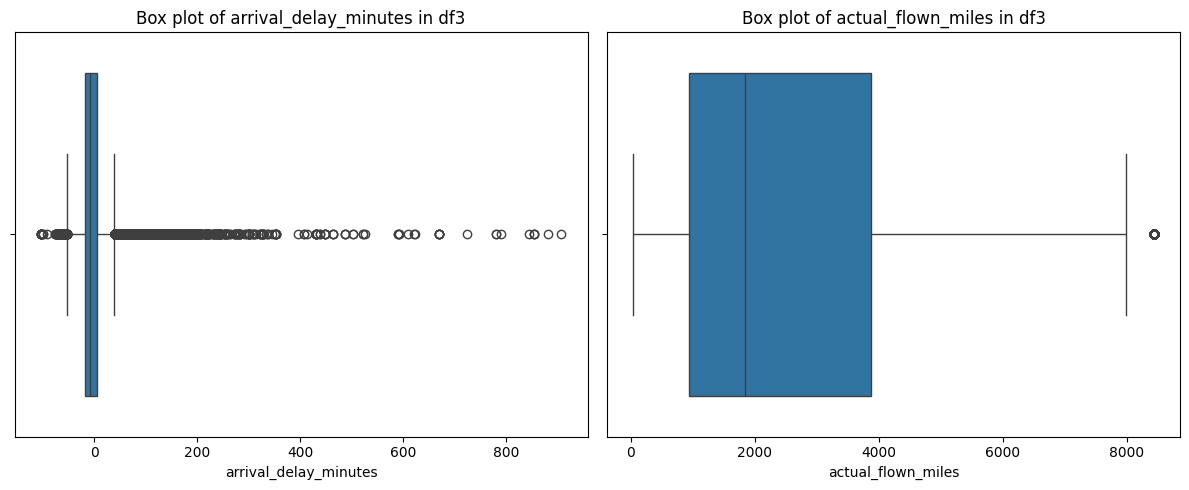

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_df3 = ['arrival_delay_minutes', 'actual_flown_miles']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols_df3):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x=df3[col])
    plt.title(f'Box plot of {col} in df3')
plt.tight_layout()
plt.show()

File4: AirlineScrappedReview Cleaning

In [34]:
import pandas as pd

# Load the dataset
df4 = pd.read_csv('/content/AirlineScrappedReview_Cleaned.csv')

# Display the head
print("Head of the DataFrame:")
display(df4.head())

# Display the tail
print("\nTail of the DataFrame:")
display(df4.tail())

# Display the info
print("\nInfo of the DataFrame:")
df4.info()

# Display the describe
print("\nDescribe of the DataFrame:")
display(df4.describe())

Head of the DataFrame:


,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
0,Paige Boet,June 2023,New Orleans to London,1,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
1,S Layne,March 2023,London to Amman,1,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,..."
2,E Lanewoski,NaN,Heathrow to Bodrum,2,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye"
3,Joel Burman,June 2023,Amman to London,4,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,NaN,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
4,R Vines,NaN,London City to Ibiza,7,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,NaN,42.953765,-81.229153,"London (city), Ontario, N6C 0A7, Canada",38.974390,1.419746,"Eivissa, Illes Balears, España"



Tail of the DataFrame:


,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
3570,W Benson,NaN,NaN,4,Not Verified,British Airways customer review,LHR-HKG on Boeing 747 - 23/08/12. Much has bee...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3571,S Luqman,NaN,NaN,4,Not Verified,British Airways customer review,Just got back from Bridgetown Barbados flying ...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3572,D Smith,NaN,NaN,4,Not Verified,British Airways customer review,LHR-JFK-LAX-LHR. Check in was ok apart from be...,Unknown,Economy Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3573,W Benson,NaN,NaN,6,Not Verified,British Airways customer review,HKG-LHR in New Club World on Boeing 777-300 - ...,Unknown,Business Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."
3574,Michael Dielissen,NaN,NaN,8,Not Verified,British Airways customer review,YYZ to LHR - July 2012 - I flew overnight in p...,Unknown,Premium Economy,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."



Info of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3574 non-null   object 
 1   Flying_Date      955 non-null    object 
 2   Route            2809 non-null   object 
 3   Rating           3575 non-null   int64  
 4   Verified         3575 non-null   object 
 5   Review_title     3575 non-null   object 
 6   Review_content   3575 non-null   object 
 7   Traveller_Type   3575 non-null   object 
 8   Class            3575 non-null   object 
 9   Start_Location   2809 non-null   object 
 10  End_Location     2809 non-null   object 
 11  Layover_Route    484 non-null    object 
 12  Start_Latitude   3515 non-null   float64
 13  Start_Longitude  3515 non-null   float64
 14  Start_Address    3515 non-null   object 
 15  End_Latitude     3476 non-null   float64
 16  End_Longitude    3476 non-null   flo

,Rating,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
count,3575.000000,3515.000000,3515.000000,3476.000000,3476.000000
mean,4.790490,42.639473,-2.164986,40.550399,-1.118816
std,3.170323,17.022014,44.576587,18.723619,46.045735
min,1.000000,-37.666951,-123.182909,-37.814245,-123.179234
25%,2.000000,41.893320,-0.458780,39.739236,-0.458780
50%,4.000000,46.314475,-0.127765,46.314475,-0.127765
75%,8.000000,51.467739,11.048029,51.467739,11.048029
max,10.000000,65.011873,151.208285,64.145981,174.550610


In [35]:
print("\nMissing values per column:")
display(df4.isnull().sum())


Missing values per column:


,0
Passanger_Name,1
Flying_Date,2620
Route,766
Rating,0
Verified,0
Review_title,0
Review_content,0
Traveller_Type,0
Class,0
Start_Location,766


In [36]:
df4['Layover_Route'] = df4['Layover_Route'].fillna('Direct')

print("\nMissing values after handling Layover_Route:")
display(df4.isnull().sum())


Missing values after handling Layover_Route:


,0
Passanger_Name,1
Flying_Date,2620
Route,766
Rating,0
Verified,0
Review_title,0
Review_content,0
Traveller_Type,0
Class,0
Start_Location,766


In [38]:
df4.dropna(subset=['Passanger_Name'], inplace=True)

print("\nMissing values after dropping row with missing 'Passanger_Name':")
display(df4.isnull().sum())


Missing values after dropping row with missing 'Passanger_Name':


,0
Passanger_Name,0
Flying_Date,2619
Route,765
Rating,0
Verified,0
Review_title,0
Review_content,0
Traveller_Type,0
Class,0
Start_Location,765


In [39]:
df4.dropna(subset=['Route', 'Start_Location', 'End_Location'], inplace=True)

print("\nMissing values after dropping rows with missing route/location info:")
display(df4.isnull().sum())


Missing values after dropping rows with missing route/location info:


,0
Passanger_Name,0
Flying_Date,1859
Route,0
Rating,0
Verified,0
Review_title,0
Review_content,0
Traveller_Type,0
Class,0
Start_Location,0


In [41]:
df4.dropna(subset=['Start_Latitude', 'Start_Longitude', 'Start_Address', 'End_Latitude', 'End_Longitude', 'End_Address'], inplace=True)

print("\nMissing values after dropping remaining location info rows:")
display(df4.isnull().sum())


Missing values after dropping remaining location info rows:


,0
Passanger_Name,0
Flying_Date,1731
Route,0
Rating,0
Verified,0
Review_title,0
Review_content,0
Traveller_Type,0
Class,0
Start_Location,0


In [42]:
print("Number of duplicate rows before dropping:", df4.duplicated().sum())

df4.drop_duplicates(inplace=True)

print("Number of duplicate rows after dropping:", df4.duplicated().sum())

Number of duplicate rows before dropping: 2
Number of duplicate rows after dropping: 0


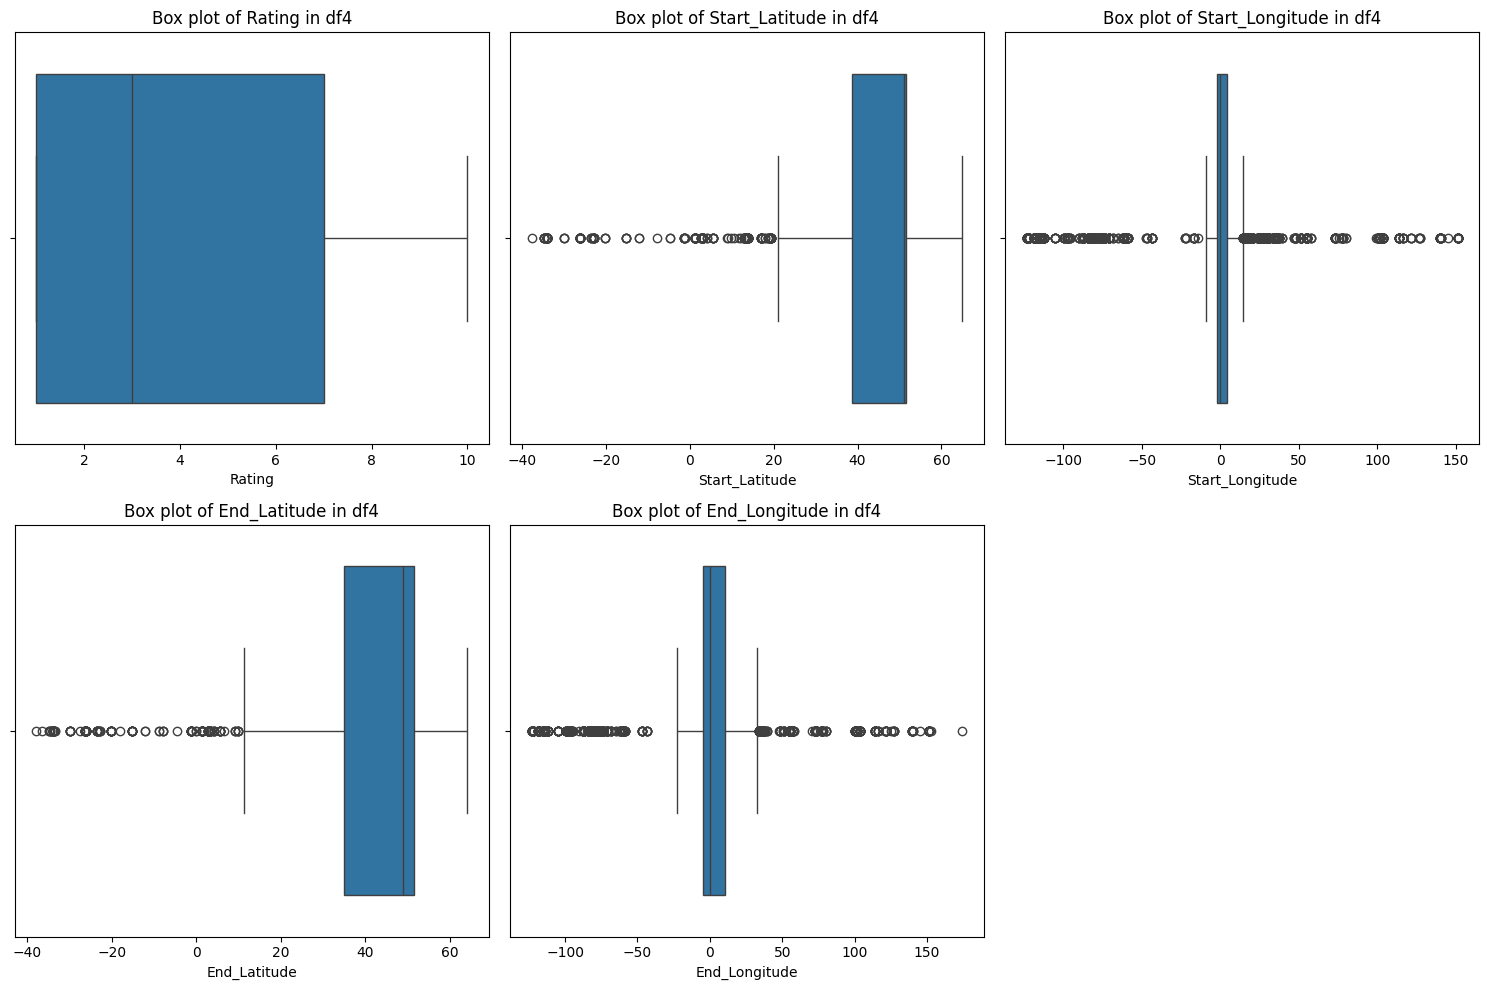

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_df4 = ['Rating', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_df4):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df4[col])
    plt.title(f'Box plot of {col} in df4')
plt.tight_layout()
plt.show()

In [44]:
# Calculate thresholds for outliers using percentiles
start_lat_lower = df4['Start_Latitude'].quantile(0.01)
start_lat_upper = df4['Start_Latitude'].quantile(0.99)
start_lon_lower = df4['Start_Longitude'].quantile(0.01)
start_lon_upper = df4['Start_Longitude'].quantile(0.99)
end_lat_lower = df4['End_Latitude'].quantile(0.01)
end_lat_upper = df4['End_Latitude'].quantile(0.99)
end_lon_lower = df4['End_Longitude'].quantile(0.01)
end_lon_upper = df4['End_Longitude'].quantile(0.99)

# Filter for rows with outlier coordinates
outlier_coords_df4 = df4[
    (df4['Start_Latitude'] < start_lat_lower) | (df4['Start_Latitude'] > start_lat_upper) |
    (df4['Start_Longitude'] < start_lon_lower) | (df4['Start_Longitude'] > start_lon_upper) |
    (df4['End_Latitude'] < end_lat_lower) | (df4['End_Latitude'] > end_lat_upper) |
    (df4['End_Longitude'] < end_lon_lower) | (df4['End_Longitude'] > end_lon_upper)
]

print("Rows with potential outlier Latitude/Longitude values:")
display(outlier_coords_df4[['Route', 'Start_Location', 'End_Location', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']].head())
display(outlier_coords_df4[['Route', 'Start_Location', 'End_Location', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']].tail())

Rows with potential outlier Latitude/Longitude values:


,Route,Start_Location,End_Location,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
18,Sydney via Singapore to London Heathrow,Singapore,Sydney,1.357107,103.819499,-33.869844,151.208285
43,Sydney to London via Singapore,Sydney,London,-33.869844,151.208285,51.507446,-0.127765
96,London Heathrow to Arlanda Stockholm,London Heathrow,Arlanda Stockholm,51.467739,-0.458780,59.646792,17.937044
109,Oslo to London,Oslo,London,59.913330,10.738970,51.507446,-0.127765
117,London to Buenos Aires,London,Buenos Aires,51.507446,-0.127765,-34.603716,-58.381642


,Route,Start_Location,End_Location,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude
2737,Singapore to Sydney,Singapore,Sydney,1.357107,103.819499,-33.869844,151.208285
2755,Helsinki to London,Helsinki,London,60.167488,24.942747,51.507446,-0.127765
2760,Sydney to Singapore,Sydney,Singapore,-33.869844,151.208285,1.357107,103.819499
2793,Buenos Aires to Heathrow,Buenos Aires,London Heathrow,-34.603716,-58.381642,51.467739,-0.458780
2811,London-Vancouver,London,Vancouver,51.507446,-0.127765,49.260872,-123.113952


### Loading and Initial Exploration of Customer Comments Data

This code loads the `Customer_comment.csv` file into a pandas DataFrame named `df`. It then displays the first and last few rows of the DataFrame (`df.head()` and `df.tail()`) to give a quick look at the data structure and content. Finally, it prints the data types and non-null counts for each column (`df.info()`) and displays descriptive statistics for the numerical columns (`df.describe()`) to understand the data's basic characteristics.

### Checking for Missing Values

This code checks for and displays the number of missing (null) values in each column of the `df` DataFrame. This helps identify columns that require missing data handling.

### Investigating Missing Transformed Text

This code filters the `df` DataFrame to show rows where the `transformed_text` column is missing (null). It then displays the `verbatim_text` and `transformed_text` for the first and last few of these rows to help understand the content and potential reasons for the missing transformed text.

### Creating an Indicator for Missing Transformed Text

This code creates a new column called `transformed_text_missing` in the `df` DataFrame. This column is a binary indicator (0 or 1), where 1 means the `transformed_text` was missing for that row, and 0 means it was present. This helps capture the information about missing text for potential use in analysis or modeling. It then displays the counts of 0s and 1s in this new column.

### Handling Missing Loyalty Program Level

This code fills the missing (null) values in the `loyalty_program_level` column of the `df` DataFrame with the string 'Unknown'. This is a common way to handle missing values in categorical columns when the missingness might be informative, allowing all rows to be kept. It then displays the count of missing values in each column again to show that the `loyalty_program_level` missing values have been handled.

### Dropping Unnecessary 'Unnamed: 0' Column

This code removes the 'Unnamed: 0' column from the `df` DataFrame. This column appears to be an unnecessary index column that was likely created when the data was saved and reloaded, and it's not needed for analysis. `inplace=True` modifies the DataFrame directly. It then displays the head of the DataFrame again to show the column has been dropped.

### Checking and Dropping Duplicate Rows

This code checks for and displays the number of duplicate rows in the `df` DataFrame. It then removes any duplicate rows found using `drop_duplicates(inplace=True)`. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Converting Scheduled Departure Date to Datetime

This code converts the data type of the `scheduled_departure_date` column in the `df` DataFrame to a datetime object. This is important for performing time-based analysis on the data. It then displays the data types of all columns (`df.info()`) to show the change.

### Loading and Initial Exploration of Passenger Booking Data

This code loads the `Passanger_booking_data.csv` file into a new pandas DataFrame named `df2`. Similar to the first dataset, it displays the head and tail, info, and descriptive statistics to get an initial understanding of this data.

### Checking for Missing Values in df2

This code checks for and displays the number of missing (null) values in each column of the `df2` DataFrame. This helps identify if this dataset requires missing data handling.

### Checking and Dropping Duplicate Rows in df2

This code checks for and displays the number of duplicate rows in the `df2` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df2 (Before Handling)

This code generates box plots for the numerical columns in `df2` (`purchase_lead`, `length_of_stay`, `flight_hour`, `flight_duration`) to visually identify potential outliers. Box plots are useful for showing the distribution of data and highlighting values that fall far from the majority.

### Investigating Outliers in purchase_lead and length_of_stay (df2)

This code filters and displays rows in `df2` that have particularly high values in the `purchase_lead` and `length_of_stay` columns, based on visual inspection of the box plots. This helps to investigate the characteristics of these outlier data points.

### Applying Capping to Outliers in purchase_lead and length_of_stay (df2)

This code handles the outliers in the `purchase_lead` and `length_of_stay` columns of `df2` by applying capping. It calculates the 95th percentile for each column and replaces any values above this threshold with the threshold value. This reduces the influence of extreme outliers. It then displays descriptive statistics to show the effect of capping on the maximum values.

### Visualizing Outliers in purchase_lead and length_of_stay (df2) After Capping

This code generates box plots again for the `purchase_lead` and `length_of_stay` columns in `df2` after capping has been applied. This allows for a visual comparison to see how the capping has affected the distribution and the appearance of outliers.

### Loading and Initial Exploration of Inflight Satisfaction Data

This code loads the `Survey data_Inflight Satisfaction Score.csv` file into a new pandas DataFrame named `df3`. It displays the head and tail, info, and descriptive statistics to get an initial understanding of this data, similar to the previous datasets.

### Checking for Missing Values in df3

This code checks for and displays the number of missing (null) values in each column of the `df3` DataFrame. This helps identify columns that require missing data handling.

### Filling Remaining Missing Satisfaction Type

This code fills any remaining missing (null) values in the `satisfaction_type` column of `df3` with the string 'Non-Scored Feedback'. This is done for entries that couldn't be inferred from the numerical score, indicating a different type of response. It then displays the updated missing value counts and the value counts for the `satisfaction_type` column.

### Investigating Remaining Missing Satisfaction Type

This code filters `df3` to show rows where `satisfaction_type` is still missing after the initial inference attempt. It displays the unique values and counts in the `score` column for these rows, and also shows sample rows including `score` and `question_text` to understand why these were not filled (likely due to non-numerical scores).

### Dropping Unnecessary 'cabin_name' Column

This code removes the 'cabin_name' column from the `df3` DataFrame. This column had a very high number of missing values and was deemed not important for the analysis goal of predicting satisfaction. Dropping it avoids dealing with extensive imputation. It displays the head and missing values after dropping.

### Analyzing Relationship Between Score and Satisfaction Type

This code filters `df3` for rows where `satisfaction_type` is not missing and displays the unique combinations of `score` and `satisfaction_type`. This was done to understand the mapping between numerical scores and satisfaction types, which was then used to infer missing `satisfaction_type` values.

### Handling Missing Arrival Gate

This code fills the missing (null) values in the `arrival_gate` column of `df3` with the string 'Unknown'. This helps to handle missing gate information by categorizing it as unknown. It then displays the updated missing value counts.

### Dropping Rows with Missing Departure Gate

This code removes rows from `df3` where the `departure_gate` column has missing (null) values. Since there were relatively few missing values in this column, dropping the rows is a straightforward way to handle them. It displays the updated missing value counts.

### Handling Missing Media Provider

This code fills the missing (null) values in the `media_provider` column of `df3` with the string 'Unknown'. This helps to handle missing information about the media provider by categorizing it as unknown. It then displays the updated missing value counts.

### Handling Missing Loyalty Program Level (df3)

This code fills the missing (null) values in the `loyalty_program_level` column of `df3` with the string 'Unknown'. This handles missing loyalty information by categorizing it as unknown. It then displays the updated missing value counts.

### Dropping Rows with Missing Entity

This code removes rows from `df3` where the `entity` column has missing (null) values. Since there were only a few missing values in this column, dropping these rows is a safe way to handle them without significant data loss. It displays the updated missing value counts.

### Checking and Dropping Duplicate Rows in df3

This code checks for and displays the number of duplicate rows in the `df3` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df3

This code generates box plots for the numerical columns in `df3` (`arrival_delay_minutes`, `actual_flown_miles`) to visually identify potential outliers. This helps understand the distribution of flight delays and distances and highlight extreme values.

### Loading and Initial Exploration of Airline Scrapped Review Data

This code loads the `AirlineScrappedReview_Cleaned.csv` file into a new pandas DataFrame named `df4`. It displays the head and tail, info, and descriptive statistics to get an initial understanding of this data, similar to the previous datasets.

### Checking for Missing Values in df4

This code checks for and displays the number of missing (null) values in each column of the `df4` DataFrame. This helps identify columns that require missing data handling.

### Handling Missing Layover Route

This code fills the missing (null) values in the `Layover_Route` column of `df4` with the string 'Direct'. This is done to indicate flights that do not have a layover route listed. It then displays the updated missing value counts.

### Dropping Row with Missing Passenger Name

This code removes the single row from `df4` where the `Passanger_Name` column has a missing (null) value. With only one missing value, dropping the row is a simple and safe way to handle it. It displays the updated missing value counts.

### Dropping Rows with Missing Route or Location Info

This code removes rows from `df4` where there are missing values in the `Route`, `Start_Location`, or `End_Location` columns. Since this location and route information is important context for reviews and difficult to impute, dropping these rows helps ensure the remaining data has complete contextual information. It displays the updated missing value counts.

### Dropping Remaining Rows with Missing Location Coordinates/Address

This code removes any remaining rows in `df4` that have missing values in the Latitude, Longitude, or Address columns (`Start_Latitude`, `Start_Longitude`, `Start_Address`, `End_Latitude`, `End_Longitude`, `End_Address`). This further cleans up incomplete location information. It displays the updated missing value counts.

### Checking and Dropping Duplicate Rows in df4

This code checks for and displays the number of duplicate rows in the `df4` DataFrame. It then removes any duplicate rows found. Finally, it checks and displays the number of duplicate rows again to confirm they have been removed.

### Visualizing Outliers in Numerical Columns of df4

This code generates box plots for the numerical columns in `df4` (`Rating`, `Start_Latitude`, `Start_Longitude`, `End_Latitude`, `End_Longitude`) to visually identify potential outliers. This helps understand the distribution of ratings and geographical coordinates and highlight extreme values.

### Investigating Rows with Outlier Latitude/Longitude (df4)

This code identifies and displays rows in `df4` that have potential outlier values in the Latitude and Longitude columns based on percentile thresholds. It shows the associated Route and Location information to help determine if these extreme coordinates represent valid but infrequent locations or potential data errors.